# Replicando trabalhos bases

Este notebook visa replicar modelos de dois trabalhos. Um é um artigo que faz uma análise do problema como multiclasse, e outro faz u review desse mesmo artigo, porém como multi label. Será replicado tanto o modelo multi classe (porém mudando a camada final da CNN para função de ativação sigmóide para classificação multi label) quanto o trabalho multi label com hiperparâmetros otimizados. Além disso, será realizado data augmentation no melhor dos modelos para observar possíveis melhorias nas métricas.

In [88]:
import numpy as np
if int(np.__version__.split('.')[0]) > 1:
  np.set_printoptions(legacy='1.25')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = [5.4, 3.6]

from sklearn.model_selection import train_test_split

import keras
from keras import layers
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from keras.utils import plot_model
from keras.models import load_model

# Find out if using GPU
gpu = !nvidia-smi -L
print(gpu[0].split(' (')[0] if gpu[0].startswith('GPU') else 'Not using GPU')

# For more GPU information, run:
# !nvidia-smi

GPU 0: Tesla P100-PCIE-16GB


In [89]:
def plots(history, xlim=None, ylim=None):
  if hasattr(history, 'history'):
    history = history.history
  plt.figure(figsize=(14, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history['loss'], '.-', label='Train loss')
  if 'val_loss' in history.keys():
    plt.plot(history['val_loss'], '.-', label='Val loss')
  plt.xlabel('Epochs');
  plt.legend();
  plt.yscale('log')
  plt.grid(which='both');
  metrics = [m for m in history.keys() if not (m == 'loss' or m.startswith('val_') or m.startswith('Unnamed'))]
  if len(metrics) == 0: return
  plt.subplot(1, 2, 2)
  plt.plot(history[metrics[0]], '.-', label='Train ' + metrics[0])
  plt.xlabel('Epochs');
  if 'val_' + metrics[0] in history.keys():
    v = list(history['val_' + metrics[0]])
    plt.plot(v, '.-', label='Val ' + metrics[0])
    plt.title(f"Val {metrics[0]}: {max(v):.1%} (max) | {v[-1]:.1%} (last)");
  plt.legend();
  plt.xlim(xlim);
  plt.ylim(ylim);
  plt.grid();

In [90]:
import pandas as pd

def dataframe_to_3d_blocks(df, drop_column='ecg_id', block_size=1000):
  
    # Remove a coluna especificada
    df_drop = df.drop(drop_column, axis=1)

    # Converte para NumPy
    X = df_drop.to_numpy()

    # Calcula o número de blocos possíveis
    n_blocks = X.shape[0] // block_size

    # Trunca o array para múltiplos exatos de block_size
    X = X[:n_blocks * block_size]

    # Reshape para 3D
    X_3d = X.reshape(n_blocks, block_size, -1)

    return X_3d


### Lendo os dados do dataset (dados já preprocessados pelo notebook no link https://www.kaggle.com/code/felipemeier/preprocessamento)

In [91]:
x_train_df = pd.read_csv('/kaggle/input/ecg-sheets/y_train_signal(1).csv')


In [92]:
x_train_df

,ecg_id,channel-0,channel-1,channel-2,channel-3,channel-4,channel-5,channel-6,channel-7,channel-8,channel-9,channel-10,channel-11
0,1,-0.119,-0.055,0.064,0.086,-0.091,0.004,-0.069,-0.031,0.000,-0.026,-0.039,-0.079
1,1,-0.116,-0.051,0.065,0.083,-0.090,0.006,-0.064,-0.036,-0.003,-0.031,-0.034,-0.074
2,1,-0.120,-0.044,0.076,0.082,-0.098,0.016,-0.058,-0.034,-0.010,-0.028,-0.029,-0.069
3,1,-0.117,-0.038,0.080,0.077,-0.098,0.021,-0.050,-0.030,-0.015,-0.023,-0.022,-0.064
4,1,-0.103,-0.031,0.072,0.066,-0.087,0.021,-0.045,-0.027,-0.020,-0.019,-0.018,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17440995,21836,0.096,0.189,0.093,-0.143,0.001,0.141,-0.034,0.189,0.162,0.227,0.183,0.128
17440996,21836,0.051,0.119,0.068,-0.085,-0.009,0.093,-0.049,0.195,0.172,0.217,0.127,0.081
17440997,21836,0.033,0.070,0.037,-0.052,-0.002,0.054,-0.097,0.140,0.215,0.218,0.101,0.052
17440998,21836,0.027,0.082,0.055,-0.055,-0.014,0.068,-0.104,0.123,0.200,0.210,0.335,0.010


Transformando os dados de sinal em um vetor de três dimensões (formato para ser inputado na CNN)

In [93]:
x_train = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/ecg-sheets/y_train_signal(1).csv'))
x_val = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/ecg-sheets/y_valid_signal(1).csv'))
x_test = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/ecg-sheets/y_test_signal(1).csv'))


In [94]:
x_train[17440,999,1]

0.051

In [95]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)


(17441, 1000, 12)
(2193, 1000, 12)
(2203, 1000, 12)


In [96]:
y_train_all = pd.read_csv('/kaggle/input/ecg-sheets/y_train(2).csv')


In [97]:
y_train_all.columns


Index(['age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'NORM',
       'MI', 'STTC', 'HYP', 'CD', 'sub_NORM', 'sub_IMI', 'sub_STTC',
       'sub_NST_', 'sub_LVH', 'sub_LAFB/LPFB', 'sub_RVH', 'sub_IRBBB',
       'sub_RAO/RAE', 'sub_IVCD', 'sub_LMI', 'sub_AMI', 'sub__AVB', 'sub_ISCA',
       'sub_ISC_', 'sub_SEHYP', 'sub_ISCI', 'sub_CRBBB', 'sub_CLBBB',
       'sub_LAO/LAE', 'sub_ILBBB', 'sub_WPW', 'sub_PMI', 'strat_fold'],
      dtype='object')

Limpando o dataframe da variável alvo para termos rotulados apenas as superclasses

In [98]:
y_train_class = y_train_all.loc[:, 'NORM':'CD']
y_train_subclass = y_train_all.loc[:, 'sub_NORM':'sub_PMI']

In [99]:
y_train_class

,NORM,MI,STTC,HYP,CD
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
17436,0,0,0,0,1
17437,0,0,1,0,0
17438,1,0,0,0,0
17439,0,0,1,0,0


Provando que é um problema multilabel

In [100]:
num_labels_per_instance = y_train_class.sum(axis=1)
multilabel_instances = np.where(num_labels_per_instance > 1)[0]
y_train_class.iloc[multilabel_instances[:10]]

,NORM,MI,STTC,HYP,CD
29,0,0,0,1,1
31,0,1,0,0,1
48,0,1,0,0,1
57,0,0,1,0,1
68,0,0,1,0,1
69,0,1,0,0,1
72,0,1,0,1,0
94,0,0,1,0,1
97,0,1,1,1,0
116,0,1,1,0,0


In [101]:
y_val_all = pd.read_csv('/kaggle/input/ecg-sheets/y_valid(1).csv')
y_val_class = y_val_all.loc[:, 'NORM':'CD']
y_val_subclass = y_val_all.loc[:, 'sub_NORM':'sub_PMI']

y_test_all = pd.read_csv('/kaggle/input/ecg-sheets/y_test(1).csv')
y_test_class = y_test_all.loc[:, 'NORM':'CD']
y_test_subclass = y_test_all.loc[:, 'sub_NORM':'sub_PMI']

In [102]:
print(y_train_class.shape)
print(y_val_class.shape)
print(y_test_class.shape)


(17441, 5)
(2193, 5)
(2203, 5)


In [103]:
print(y_train_subclass.shape)
print(y_val_subclass.shape)
print(y_test_subclass.shape)

(17441, 23)
(2193, 23)
(2203, 23)


In [104]:
x_train

array([[[-1.190e-01, -5.500e-02,  6.400e-02, ..., -2.600e-02,
         -3.900e-02, -7.900e-02],
        [-1.160e-01, -5.100e-02,  6.500e-02, ..., -3.100e-02,
         -3.400e-02, -7.400e-02],
        [-1.200e-01, -4.400e-02,  7.600e-02, ..., -2.800e-02,
         -2.900e-02, -6.900e-02],
        ...,
        [ 6.900e-02,  0.000e+00, -6.900e-02, ...,  2.400e-02,
         -4.100e-02, -5.800e-02],
        [ 8.600e-02,  4.000e-03, -8.100e-02, ...,  2.420e-01,
         -4.600e-02, -9.800e-02],
        [ 2.200e-02, -3.100e-02, -5.400e-02, ...,  1.430e-01,
         -3.500e-02, -1.200e-01]],

       [[ 4.000e-03,  1.380e-01,  1.340e-01, ...,  1.920e-01,
          8.300e-02,  8.800e-02],
        [-2.000e-02,  1.160e-01,  1.360e-01, ...,  1.560e-01,
          5.700e-02,  6.300e-02],
        [-5.300e-02,  9.200e-02,  1.450e-01, ...,  1.070e-01,
          1.300e-02,  2.200e-02],
        ...,
        [ 1.210e-01,  3.980e-01,  2.770e-01, ..., -1.065e+00,
         -4.920e-01, -1.560e-01],
        [-3.

Filtrando os dados que estão rotulados com [0,0,0,0,0]

In [105]:
y_train_class

,NORM,MI,STTC,HYP,CD
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
17436,0,0,0,0,1
17437,0,0,1,0,0
17438,1,0,0,0,0
17439,0,0,1,0,0


In [106]:

# Cria uma máscara booleana para identificar quais amostras têm pelo menos um rótulo
mascara_rotulados = y_train_class.sum(axis=1) > 0

# Aplica a máscara ao y_train_class e x_train
y_train_class = y_train_class[mascara_rotulados]
x_train = x_train[mascara_rotulados.values]  # .values para garantir compatibilidade com numpy

# Verifica os novos tamanhos
print(x_train.shape)
print(y_train_class.shape)
print(mascara_rotulados)


(17111, 1000, 12)
(17111, 5)
0        True
1        True
2        True
3        True
4        True
         ... 
17436    True
17437    True
17438    True
17439    True
17440    True
Length: 17441, dtype: bool


In [107]:
y_val_class

,NORM,MI,STTC,HYP,CD
0,0,1,0,0,0
1,1,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
...,...,...,...,...,...
2188,1,0,0,0,0
2189,0,1,0,0,0
2190,0,0,0,0,0
2191,1,0,0,0,0


In [108]:

# Cria uma máscara booleana para identificar quais amostras têm pelo menos um rótulo
mascara_rotulados = y_val_class.sum(axis=1) > 0

# Aplica a máscara ao y_train_class e x_train
y_val_class = y_val_class[mascara_rotulados]
x_val = x_val[mascara_rotulados.values]  # .values para garantir compatibilidade com numpy

# Verifica os novos tamanhos
print(x_val.shape)
print(y_val_class.shape)
print(mascara_rotulados)


(2156, 1000, 12)
(2156, 5)
0        True
1        True
2       False
3       False
4       False
        ...  
2188     True
2189     True
2190    False
2191     True
2192     True
Length: 2193, dtype: bool


In [109]:
y_test_class

,NORM,MI,STTC,HYP,CD
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
2198,1,0,0,0,0
2199,0,0,0,0,1
2200,1,0,0,0,0
2201,0,0,0,0,1


In [110]:

# Cria uma máscara booleana para identificar quais amostras têm pelo menos um rótulo
mascara_rotulados = y_test_class.sum(axis=1) > 0

# Aplica a máscara ao y_train_class e x_train
y_test_class = y_test_class[mascara_rotulados]
x_test = x_test[mascara_rotulados.values]  # .values para garantir compatibilidade com numpy

# Verifica os novos tamanhos
print(x_test.shape)
print(y_test_class.shape)
print(mascara_rotulados)


(2163, 1000, 12)
(2163, 5)
0       True
1       True
2       True
3       True
4       True
        ... 
2198    True
2199    True
2200    True
2201    True
2202    True
Length: 2203, dtype: bool


É necessário criar uma métrica própria de acurácia para o problema multilabel

In [111]:
import tensorflow.keras.backend as K

def own_accuracy(y_true, y_pred):
    y_true = K.cast(y_true, K.floatx())  # converte para float32
    y_pred_binary = K.cast(K.greater(y_pred, 0.5), K.floatx())  # binariza

    correct = K.cast(K.equal(y_true, y_pred_binary), K.floatx())  # acertos por label
    return K.mean(correct)  # média geral dos acertos

Função de treino (com a métrica ROC AUC)

In [112]:
import tensorflow as tf

class AUC_Macro(tf.keras.metrics.Metric):
    def __init__(self, num_labels, name="auc_macro", **kwargs):
        super(AUC_Macro, self).__init__(name=name, **kwargs)
        self.num_labels = num_labels
        # Cria uma lista de AUCs individuais para cada label
        self.auc_per_label = [tf.keras.metrics.AUC(name=f'auc_label_{i}') for i in range(num_labels)]
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Atualiza cada AUC para cada label
        for i in range(self.num_labels):
            self.auc_per_label[i].update_state(y_true[:, i], y_pred[:, i], sample_weight)
    
    def result(self):
        # Calcula a média das AUCs individuais
        aucs = [auc.result() for auc in self.auc_per_label]
        return tf.reduce_mean(aucs)
    
    def reset_states(self):
        for auc in self.auc_per_label:
            auc.reset_states()


In [113]:
def train_class(model, epochs, batch_size, lr, callbacks, n_classes):
    from tqdm.keras import TqdmCallback
    import tensorflow as tf
    from tensorflow import keras

    auc_macro = AUC_Macro(num_labels=n_classes)

    callbacks = callbacks + [TqdmCallback(verbose=0)]
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[auc_macro]
    )
    history = model.fit(
        x_train, y_train_class,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_val, y_val_class),
        callbacks=callbacks,
        verbose=1  # mostra progresso no terminal
    )
    return history


# Um primeiro modelo (feito por nós)

In [114]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(112, kernel_size=3),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Conv1D(64, kernel_size=3),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Conv1D(128, kernel_size=2),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Conv1D(96, kernel_size=5),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Conv1D(96, kernel_size=3),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Conv1D(112, kernel_size=5),
    layers.LeakyReLU(negative_slope=0.0088),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(5, activation='sigmoid')  # 5 saídas para classificação multi-label
])


model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_41 (Conv1D)                   │ (None, 998, 112)            │           4,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_41 (LeakyReLU)           │ (None, 998, 112)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_42 (Conv1D)                   │ (None, 996, 64)             │          21,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_42 (LeakyReLU)           │ (None, 996, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_43 (Conv1D)                   │ (None, 995, 128)            │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_43 (LeakyReLU)           │ (None, 995, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_44 (Conv1D)                   │ (None, 991, 96)             │          61,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_44 (LeakyReLU)           │ (None, 991, 96)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_45 (Conv1D)                   │ (None, 989, 96)             │          27,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_45 (LeakyReLU)           │ (None, 989, 96)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_46 (Conv1D)                   │ (None, 985, 112)            │          53,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_46 (LeakyReLU)           │ (None, 985, 112)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 110320)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 110320)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 5)                   │         551,605 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 736,981 (2.81 MB)

 Trainable params: 736,981 (2.81 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

0epoch [00:00, ?epoch/s]

Epoch 1/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - auc_macro: 0.7595 - loss: 0.4506 - val_auc_macro: 0.8794 - val_loss: 0.3569 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc_macro: 0.8948 - loss: 0.3177 - val_auc_macro: 0.8918 - val_loss: 0.3524 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - auc_macro: 0.9263 - loss: 0.2759 - val_auc_macro: 0.8943 - val_loss: 0.3249 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc_macro: 0.9515 - loss: 0.2241 - val_auc_macro: 0.8886 - val_loss: 0.3503 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc_macro: 0.9696 - loss: 0.1797 - val_auc_macro: 0.8735 - val_loss: 0.3966 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - auc_macro: 0.9835 - loss: 0.1326 - val_auc_macro: 0.8558 - val_loss: 0.4485 - learning_rate: 0.0011
Epoch 7/100
1068/1070 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step -

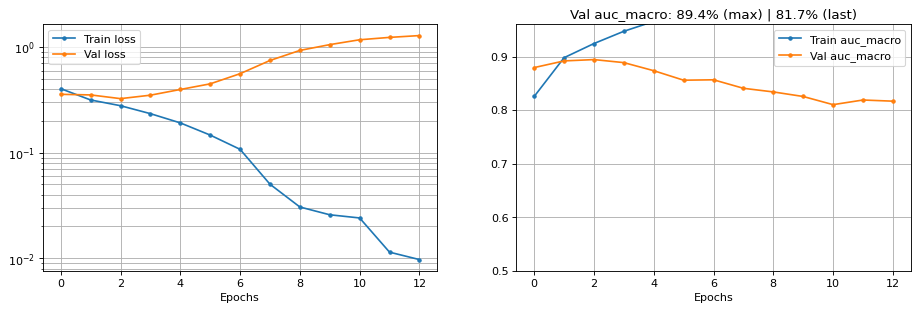

In [116]:
history = train_class(model, epochs=100, batch_size=16, lr=0.0011, callbacks=[EarlyStopping(patience=10), reduce_lr],n_classes=5)
plots(history, ylim=[0.5, 0.96])


In [117]:
# Avaliação com Keras
val_loss, val_own_acc = model.evaluate(x_val, y_val_class, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation own_accuracy: {val_own_acc:.4f}")
val_model1_results_df = pd.DataFrame({
    'loss': [val_loss],
    'own_accuracy': [val_own_acc]
})

Validation loss: 1.2848
Validation own_accuracy: 0.8166


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Validation Macro AUC: 0.8657
Validation AUC Classe 0: 0.8984
Validation AUC Classe 1: 0.8824
Validation AUC Classe 2: 0.8789
Validation AUC Classe 3: 0.8002
Validation AUC Classe 4: 0.8687


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,1.284839,0.816634,0.865712,0.898408,0.882362,0.878919,0.800186,0.868683


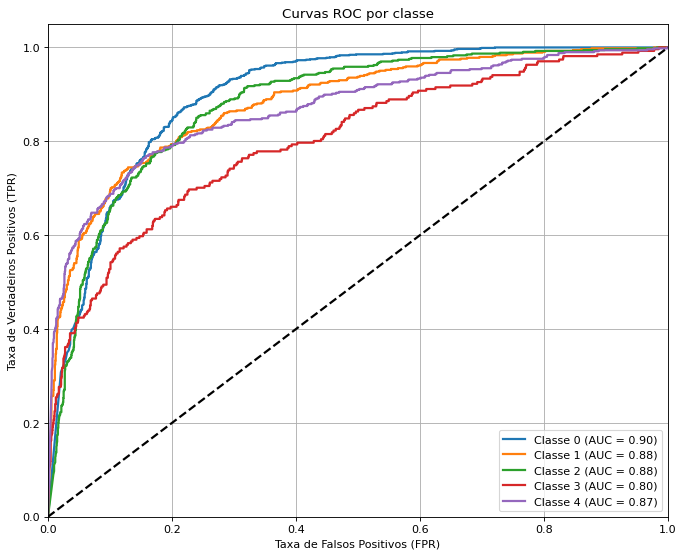

In [118]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_val_true = y_val_class.to_numpy() if hasattr(y_val_class, 'to_numpy') else y_val_class
y_val_pred = model.predict(x_val)

# AUC macro
auc_macro_val = roc_auc_score(y_val_true, y_val_pred, average='macro')
print(f"Validation Macro AUC: {auc_macro_val:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_val_true.shape[1]):
    class_auc = roc_auc_score(y_val_true[:, i], y_val_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Validation AUC Classe {i}: {class_auc:.4f}")


val_model1_results_df['auc_macro'] = auc_macro_val
for i, auc_val in enumerate(auc_per_class):
    val_model1_results_df[f'auc_class_{i}'] = auc_val

display(val_model1_results_df)


n_classes = y_val_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_true[:, i], y_val_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [119]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model1_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 1.3485
Acurácia no Teste: 0.8085


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Test Macro AUC: 0.8585
Test AUC Classe 0: 0.8917
Test AUC Classe 1: 0.8689
Test AUC Classe 2: 0.8858
Test AUC Classe 3: 0.8031
Test AUC Classe 4: 0.8428


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,1.348525,0.808508,0.85848,0.891681,0.868923,0.885849,0.803129,0.842821


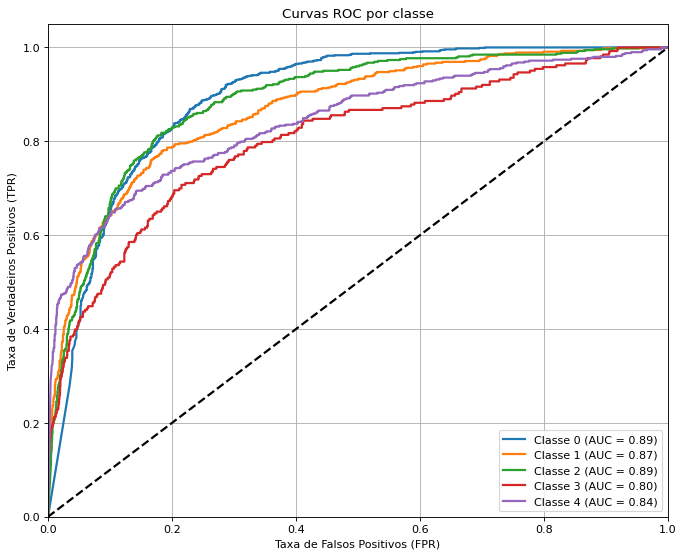

In [120]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model1_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model1_results_df[f'auc_class_{i}'] = auc_test

display(test_model1_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Conjunto de teste

In [121]:
val_model1_results_df.index = ["validação nosso modelo"]
test_model1_results_df.index = ["teste nosso modelo"]

# Concatene os dois dataframes
resultados_df = test_model1_results_df

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.85848,0.891681,0.868923,0.885849,0.803129,0.842821


# Modelo Sofia (mesmo que no artigo do Smigle mas com função de ativação da última camada sigmóide para o problema multi label)

In [122]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_47 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_47 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_48 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_48 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_49 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_49 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_50 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_50 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_51 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_51 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_7           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,765 (53.77 KB)

 Trainable params: 13,765 (53.77 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

0epoch [00:00, ?epoch/s]

Epoch 1/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - auc_macro: 0.6783 - loss: 0.5095 - val_auc_macro: 0.8451 - val_loss: 0.3916 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8503 - loss: 0.3775 - val_auc_macro: 0.8642 - val_loss: 0.3727 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8719 - loss: 0.3502 - val_auc_macro: 0.8776 - val_loss: 0.3465 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8866 - loss: 0.3322 - val_auc_macro: 0.8847 - val_loss: 0.3402 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8937 - loss: 0.3228 - val_auc_macro: 0.8873 - val_loss: 0.3421 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.9025 - loss: 0.3095 - val_auc_macro: 0.8964 - val_loss: 0.3241 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - 

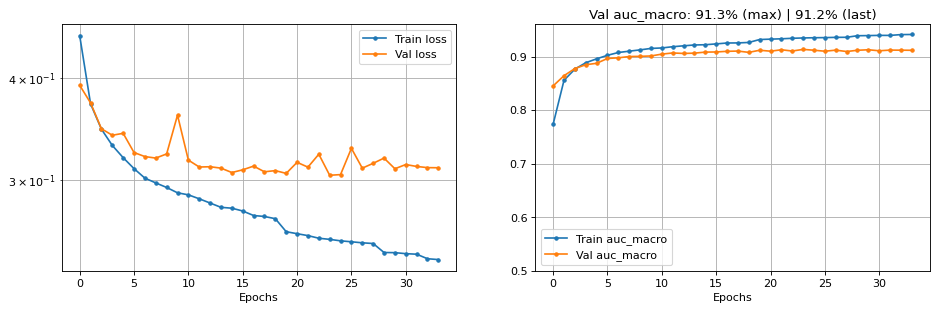

In [124]:
history = train_class(model, epochs=100, batch_size=16, lr=0.0011, callbacks=[EarlyStopping(patience=10,restore_best_weights= True), reduce_lr], n_classes=5)
plots(history, ylim=[0.5, 0.96])


In [125]:
# Avaliação com Keras
val_loss, val_own_acc = model.evaluate(x_val, y_val_class, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation own_accuracy: {val_own_acc:.4f}")
val_model2_results_df = pd.DataFrame({
    'loss': [val_loss],
    'own_accuracy': [val_own_acc]
})

Validation loss: 0.3040
Validation own_accuracy: 0.9133


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Validation Macro AUC: 0.9134
Validation AUC Classe 0: 0.9351
Validation AUC Classe 1: 0.9195
Validation AUC Classe 2: 0.9159
Validation AUC Classe 3: 0.8942
Validation AUC Classe 4: 0.9025


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.303974,0.913297,0.91345,0.935063,0.919472,0.915926,0.894244,0.902545


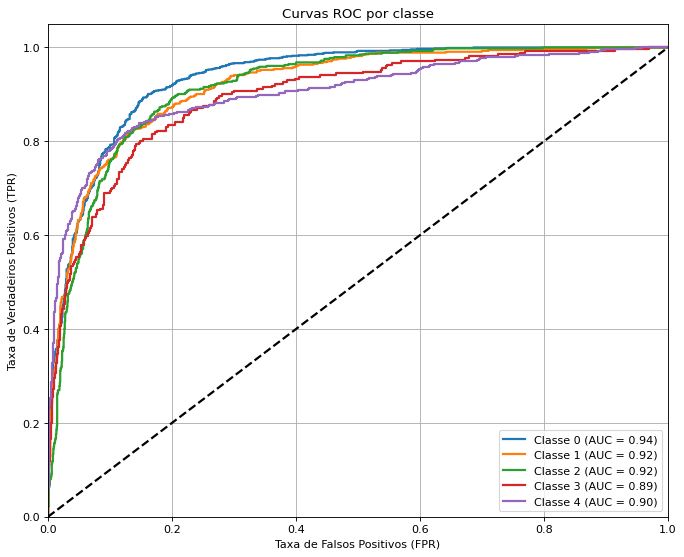

In [126]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_val_true = y_val_class.to_numpy() if hasattr(y_val_class, 'to_numpy') else y_val_class
y_val_pred = model.predict(x_val)

# AUC macro
auc_macro_val = roc_auc_score(y_val_true, y_val_pred, average='macro')
print(f"Validation Macro AUC: {auc_macro_val:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_val_true.shape[1]):
    class_auc = roc_auc_score(y_val_true[:, i], y_val_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Validation AUC Classe {i}: {class_auc:.4f}")


val_model2_results_df['auc_macro'] = auc_macro_val
for i, auc_val in enumerate(auc_per_class):
    val_model2_results_df[f'auc_class_{i}'] = auc_val

display(val_model2_results_df)


n_classes = y_val_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_true[:, i], y_val_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [127]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model2_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.3016
Acurácia no Teste: 0.9085


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Macro AUC: 0.9088
Test AUC Classe 0: 0.9280
Test AUC Classe 1: 0.9189
Test AUC Classe 2: 0.9227
Test AUC Classe 3: 0.8777
Test AUC Classe 4: 0.8968


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839


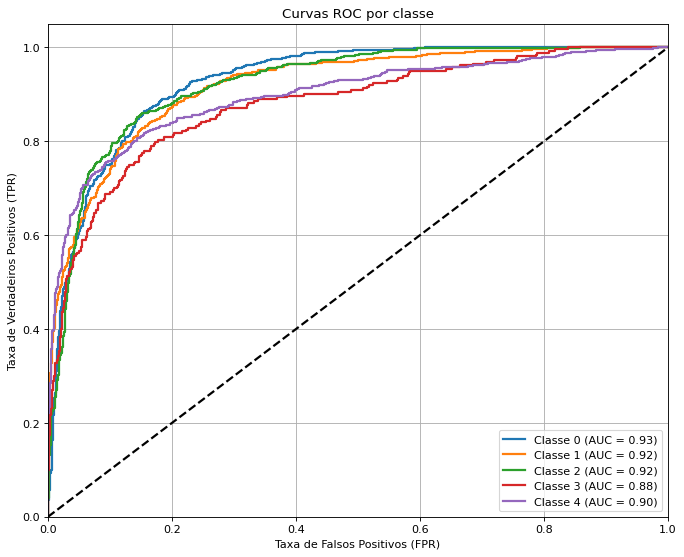

In [128]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model2_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model2_results_df[f'auc_class_{i}'] = auc_test

display(test_model2_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [129]:
val_model2_results_df.index = ["validação modelo smiegel multi label"]
test_model2_results_df.index = ["teste modelo smiegel multi label"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model2_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839


# Modelo Sofia (com hiperparâmetros otimizado) e com batch normalization

In [130]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_52 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_52 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_53 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_53 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_54 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_54 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_55 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_55 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_56 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_56 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_8           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,893 (54.27 KB)

 Trainable params: 13,829 (54.02 KB)

 Non-trainable params: 64 (256.00 B)

In [131]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

0epoch [00:00, ?epoch/s]

Epoch 1/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - auc_macro: 0.7016 - loss: 0.4902 - val_auc_macro: 0.8477 - val_loss: 0.3846 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8602 - loss: 0.3628 - val_auc_macro: 0.8763 - val_loss: 0.3489 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8820 - loss: 0.3350 - val_auc_macro: 0.8860 - val_loss: 0.3415 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8920 - loss: 0.3229 - val_auc_macro: 0.8908 - val_loss: 0.3298 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8987 - loss: 0.3097 - val_auc_macro: 0.8995 - val_loss: 0.3180 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.9049 - loss: 0.3009 - val_auc_macro: 0.9019 - val_loss: 0.3158 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step -

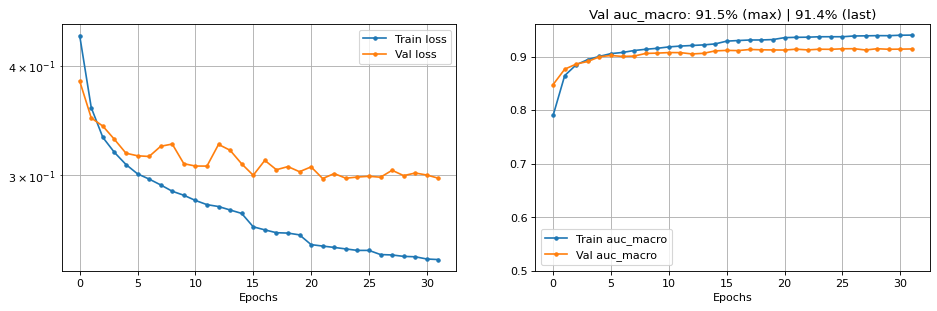

In [132]:
history = train_class(model, epochs=100, batch_size=16, lr=0.0011, callbacks=[EarlyStopping(patience=10), reduce_lr], n_classes=5)
plots(history, ylim=[0.5, 0.96])


In [133]:
# Avaliação com Keras
val_loss, val_own_acc = model.evaluate(x_val, y_val_class, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation own_accuracy: {val_own_acc:.4f}")
val_model3_results_df = pd.DataFrame({
    'loss': [val_loss],
    'own_accuracy': [val_own_acc]
})

Validation loss: 0.2977
Validation own_accuracy: 0.9141


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Validation Macro AUC: 0.9142
Validation AUC Classe 0: 0.9329
Validation AUC Classe 1: 0.9236
Validation AUC Classe 2: 0.9178
Validation AUC Classe 3: 0.8855
Validation AUC Classe 4: 0.9110


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.297661,0.914117,0.914152,0.932878,0.923618,0.917784,0.885476,0.911003


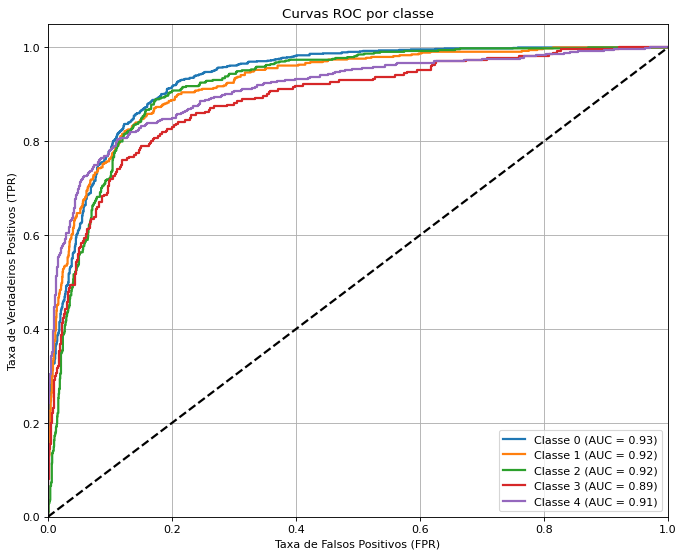

In [134]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_val_true = y_val_class.to_numpy() if hasattr(y_val_class, 'to_numpy') else y_val_class
y_val_pred = model.predict(x_val)

# AUC macro
auc_macro_val = roc_auc_score(y_val_true, y_val_pred, average='macro')
print(f"Validation Macro AUC: {auc_macro_val:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_val_true.shape[1]):
    class_auc = roc_auc_score(y_val_true[:, i], y_val_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Validation AUC Classe {i}: {class_auc:.4f}")


val_model3_results_df['auc_macro'] = auc_macro_val
for i, auc_val in enumerate(auc_per_class):
    val_model3_results_df[f'auc_class_{i}'] = auc_val

display(val_model3_results_df)


n_classes = y_val_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_true[:, i], y_val_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [135]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model3_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.2919
Acurácia no Teste: 0.9131


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Macro AUC: 0.9131
Test AUC Classe 0: 0.9343
Test AUC Classe 1: 0.9249
Test AUC Classe 2: 0.9224
Test AUC Classe 3: 0.8797
Test AUC Classe 4: 0.9041


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085


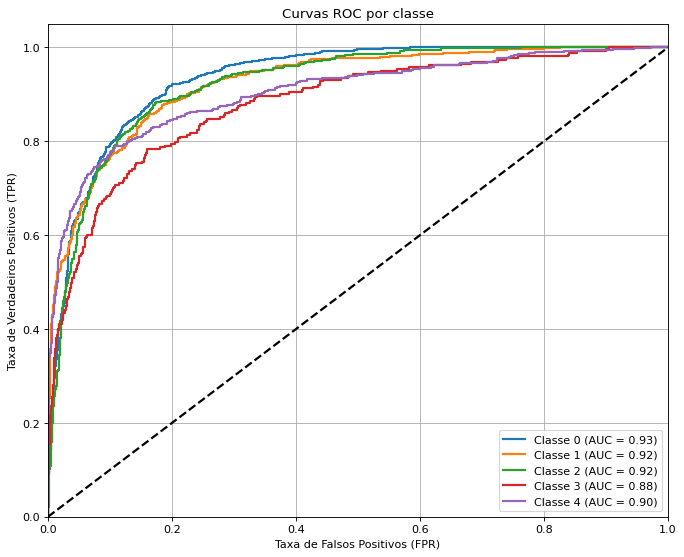

In [136]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model3_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model3_results_df[f'auc_class_{i}'] = auc_test

display(test_model3_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [137]:
val_model3_results_df.index = ["validação modelo sofia (otimizado, com batch normalization)"]
test_model3_results_df.index = ["teste modelo sofia (otimizado, com batch normalization)"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model3_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085


# Modelo Sofia sem batch normalization

In [138]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.01),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_57 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_57 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_58 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_58 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_59 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_59 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_60 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_60 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_61 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_61 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_9           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,765 (53.77 KB)

 Trainable params: 13,765 (53.77 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

0epoch [00:00, ?epoch/s]

Epoch 1/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - auc_macro: 0.6700 - loss: 0.5086 - val_auc_macro: 0.8368 - val_loss: 0.4132 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8461 - loss: 0.3831 - val_auc_macro: 0.8663 - val_loss: 0.3650 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8744 - loss: 0.3508 - val_auc_macro: 0.8736 - val_loss: 0.3549 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8851 - loss: 0.3355 - val_auc_macro: 0.8792 - val_loss: 0.3475 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8943 - loss: 0.3220 - val_auc_macro: 0.8888 - val_loss: 0.3365 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8982 - loss: 0.3163 - val_auc_macro: 0.8901 - val_loss: 0.3482 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - 

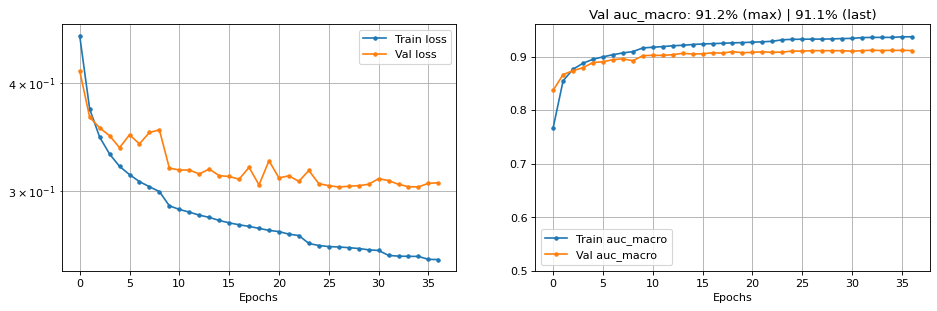

In [140]:
history = train_class(model, epochs=100, batch_size=16, lr=0.0011, callbacks=[EarlyStopping(patience=10,restore_best_weights= True), reduce_lr], n_classes=5)
plots(history, ylim=[0.5, 0.96])


In [141]:
# Avaliação com Keras
val_loss, val_own_acc = model.evaluate(x_val, y_val_class, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation own_accuracy: {val_own_acc:.4f}")
val_model4_results_df = pd.DataFrame({
    'loss': [val_loss],
    'own_accuracy': [val_own_acc]
})

Validation loss: 0.3030
Validation own_accuracy: 0.9109


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Validation Macro AUC: 0.9111
Validation AUC Classe 0: 0.9301
Validation AUC Classe 1: 0.9184
Validation AUC Classe 2: 0.9164
Validation AUC Classe 3: 0.8902
Validation AUC Classe 4: 0.9004


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.30299,0.910945,0.911066,0.930054,0.918367,0.916366,0.890188,0.900357


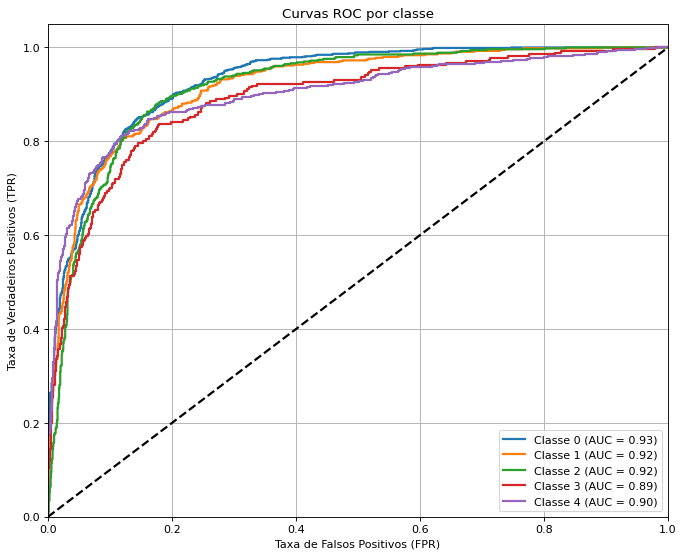

In [142]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_val_true = y_val_class.to_numpy() if hasattr(y_val_class, 'to_numpy') else y_val_class
y_val_pred = model.predict(x_val)

# AUC macro
auc_macro_val = roc_auc_score(y_val_true, y_val_pred, average='macro')
print(f"Validation Macro AUC: {auc_macro_val:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_val_true.shape[1]):
    class_auc = roc_auc_score(y_val_true[:, i], y_val_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Validation AUC Classe {i}: {class_auc:.4f}")


val_model4_results_df['auc_macro'] = auc_macro_val
for i, auc_val in enumerate(auc_per_class):
    val_model4_results_df[f'auc_class_{i}'] = auc_val

display(val_model4_results_df)


n_classes = y_val_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_true[:, i], y_val_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [143]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model4_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.3026
Acurácia no Teste: 0.9061


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Macro AUC: 0.9061
Test AUC Classe 0: 0.9288
Test AUC Classe 1: 0.9140
Test AUC Classe 2: 0.9160
Test AUC Classe 3: 0.8785
Test AUC Classe 4: 0.8932


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.89324


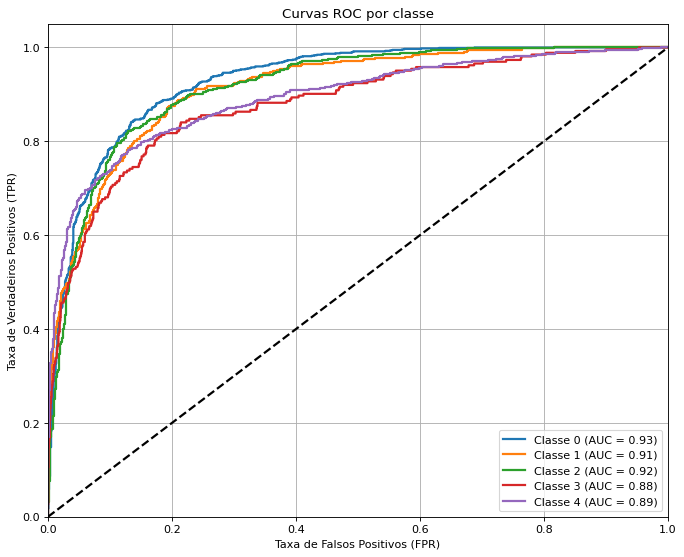

In [144]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model4_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model4_results_df[f'auc_class_{i}'] = auc_test

display(test_model4_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [145]:
val_model4_results_df.index = ["validação modelo sofia (otimizado, sem batch normalization)"]
test_model4_results_df.index = ["teste modelo sofia (otimizado, sem batch normalization)"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model4_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085
"teste modelo sofia (otimizado, sem batch normalization)",0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.893240


# Data Augmentation

Realizou-se data augmentation nas séries temporais se utilizando o modelo que até então teve os melhores resultados. O data augmentation será aplicado aleatoriamente entre as amostras (ocorrendo amostras com data augmentation e sem). Isso será feito com a classe abaixo:

Primeira data augmentation: Cortar aleatoriamente de 0 a 1 segundo no começo e no final do sinal, preenchendo com zeros

In [146]:
def cut_and_pad(ecg, cut=100):
    # ecg shape: (1000, 12)
    start = np.random.randint(0, cut)
    end = cut - start
    ecg_cut = ecg[start:1000-end]
    # Padding no começo e fim
    pad_start = np.zeros((start, ecg.shape[1]))
    pad_end = np.zeros((end, ecg.shape[1]))
    ecg_aug = np.vstack([pad_start, ecg_cut, pad_end])
    return ecg_aug


Segundo data augmentation: Time shift

In [147]:
def time_shift(ecg, shift_max=100):
    shift = np.random.randint(-shift_max, shift_max)
    if shift > 0:
        ecg_shifted = np.pad(ecg[:-shift], ((shift, 0), (0, 0)), mode='constant')
    elif shift < 0:
        ecg_shifted = np.pad(ecg[-shift:], ((0, -shift), (0, 0)), mode='constant')
    else:
        ecg_shifted = ecg.copy()
    return ecg_shifted


Terceiro data augmentation: Ruído gaussiano leve

In [148]:
def add_noise(ecg, noise_level=0.1):
    noise = np.random.normal(0, noise_level, ecg.shape)
    return ecg + noise


Quarto data augmentation: Escala de amplitude

In [149]:
def scale_amplitude(ecg, scale_range=(0.8, 1.2)):
    factor = np.random.uniform(*scale_range)
    return ecg * factor


In [150]:
from tensorflow.keras.utils import Sequence

class ECGDataGenerator(Sequence):
    def __init__(self, x_data, y_data, flag,batch_size=32, augment_prob=0.5, shuffle=True):
        self.x_data = x_data
        self.y_data = y_data
        self.batch_size = batch_size
        self.augment_prob = augment_prob
        self.shuffle = shuffle
        self.flag = flag
        self.indices = np.arange(len(self.x_data))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x_data) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        x_batch = self.x_data[batch_indices]
        y_batch = self.y_data[batch_indices]

        # Aplica o augmentation aleatoriamente
        x_aug = []
        for ecg in x_batch:
            if (np.random.rand() < self.augment_prob) & (self.flag==1):
                ecg = cut_and_pad(ecg)
            elif (np.random.rand() < self.augment_prob) & (self.flag==2):
                ecg = time_shift(ecg)
            elif (np.random.rand() < self.augment_prob) & (self.flag==3):
                ecg = add_noise(ecg)
            elif (np.random.rand() < self.augment_prob) & (self.flag==4):
                ecg = scale_amplitude(ecg)
            x_aug.append(ecg)
        x_aug = np.array(x_aug)

        return x_aug, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def plot_augmented_examples(self, n=6, channel=0):
        """Plota n exemplos de sinais com e sem data augmentation."""
        indices = np.random.choice(len(self.x_data), size=n, replace=False)
        samples = self.x_data[indices]
        augmented_samples = []

        for ecg in samples:
            ecg_aug = ecg.copy()
            if self.flag == 1:
                ecg_aug = cut_and_pad(ecg_aug)
            elif self.flag == 2:
                ecg_aug = time_shift(ecg_aug)
            elif self.flag == 3:
                ecg_aug = add_noise(ecg_aug)
            elif self.flag == 4:
                ecg_aug = scale_amplitude(ecg_aug)
            augmented_samples.append(ecg_aug)

        fig, axes = plt.subplots(nrows=n//3, ncols=3, figsize=(18, 6))
        axes = axes.flatten()

        for i in range(n):
            axes[i].plot(samples[i][:, channel], label='Original', alpha=0.6)
            axes[i].plot(augmented_samples[i][:, channel], label='Augmentado', alpha=0.8)
            axes[i].set_title(f"Amostra {indices[i]} - Canal {channel}")
            axes[i].legend()
            axes[i].set_xlabel("Tempo (amostras)")
            axes[i].set_ylabel("Amplitude")

        plt.tight_layout()
        plt.show()
    

In [151]:
def train_class(model, x_train, y_train_class, x_val, y_val_class, flag,
                epochs, batch_size, lr, callbacks, n_classes,
                augment_prob=0.5):
    
    
    # Data generator com data augmentation no treino e sem no validation
    train_generator = ECGDataGenerator(x_train, y_train_class,flag, batch_size=batch_size, augment_prob=augment_prob)
    train_generator.plot_augmented_examples(n=6, channel=0)
    val_generator = ECGDataGenerator(x_val, y_val_class,flag, batch_size=batch_size, augment_prob=0.0)

    auc_macro = AUC_Macro(num_labels=n_classes)

    callbacks = callbacks + [TqdmCallback(verbose=0)]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[auc_macro]
    )

    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )
    return history


In [152]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_62 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_62 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_63 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_63 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_64 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_64 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_65 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_65 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_66 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_66 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_10          │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,893 (54.27 KB)

 Trainable params: 13,829 (54.02 KB)

 Non-trainable params: 64 (256.00 B)

In [153]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)

In [154]:
y_train_class

,NORM,MI,STTC,HYP,CD
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
17436,0,0,0,0,1
17437,0,0,1,0,0
17438,1,0,0,0,0
17439,0,0,1,0,0


In [155]:
y_train_class = y_train_class.to_numpy()  # ou .values
y_val_class = y_val_class.to_numpy()


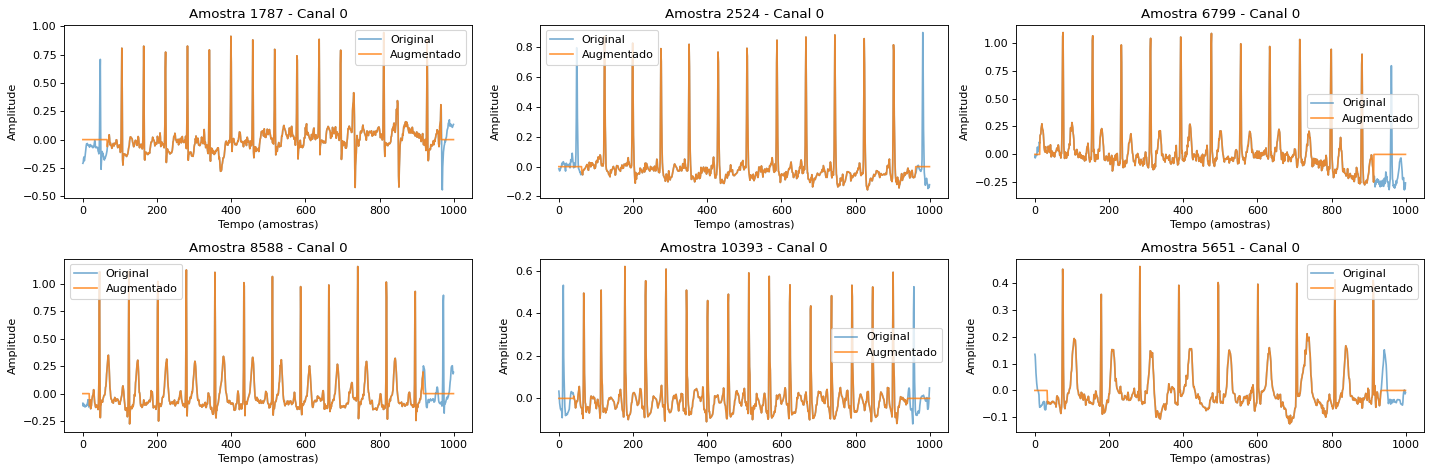

0epoch [00:00, ?epoch/s]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1070/1070 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc_macro: 0.7026 - loss: 0.4854 - val_auc_macro: 0.8453 - val_loss: 0.3877 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.8640 - loss: 0.3611 - val_auc_macro: 0.8800 - val_loss: 0.3443 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.8809 - loss: 0.3368 - val_auc_macro: 0.8913 - val_loss: 0.3332 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_macro: 0.8933 - loss: 0.3187 - val_auc_macro: 0.8934 - val_loss: 0.3269 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.9025 - loss: 0.3073 - val_auc_macro: 0.8933 - val_loss: 0.3258 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.9066 - loss: 0.2985 - val_auc_macro: 0.8981 - val_loss: 0.3287 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 

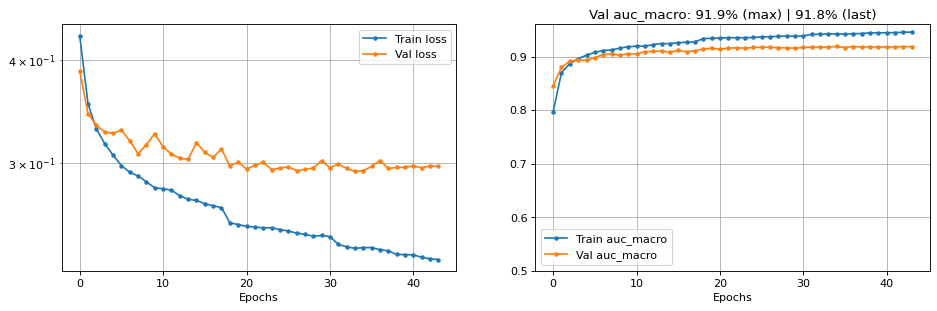

In [156]:
from tqdm.keras import TqdmCallback
history = train_class(
    model,
    x_train, y_train_class,
    x_val, y_val_class,
    flag = 1,
    epochs=100,
    batch_size=16,
    lr=0.0011,  
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        reduce_lr  
    ],
    n_classes=5
)
plots(history, ylim=[0.5, 0.96])

### Conjunto de teste - Data Aug 1

In [157]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model5_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.2927
Acurácia no Teste: 0.9133


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Macro AUC: 0.9132
Test AUC Classe 0: 0.9351
Test AUC Classe 1: 0.9258
Test AUC Classe 2: 0.9267
Test AUC Classe 3: 0.8816
Test AUC Classe 4: 0.8971


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.292726,0.913318,0.913242,0.935122,0.92577,0.926661,0.881597,0.897061


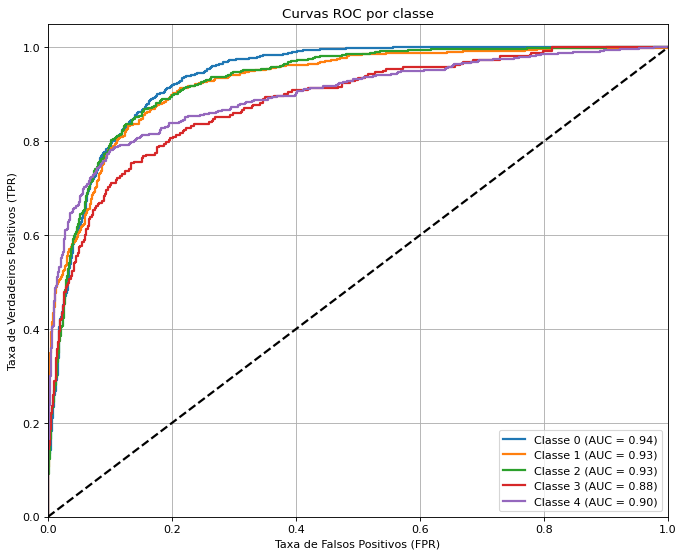

In [158]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model5_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model5_results_df[f'auc_class_{i}'] = auc_test

display(test_model5_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [159]:
test_model5_results_df.index = ["teste modelo data augmentation padding 0"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model5_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085
"teste modelo sofia (otimizado, sem batch normalization)",0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.893240
teste modelo data augmentation padding 0,0.292726,0.913318,0.913242,0.935122,0.925770,0.926661,0.881597,0.897061


### Data augmentation 2

In [160]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_67 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_67 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_68 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_68 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_69 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_69 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_70 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_70 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_71 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_71 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_11          │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,893 (54.27 KB)

 Trainable params: 13,829 (54.02 KB)

 Non-trainable params: 64 (256.00 B)

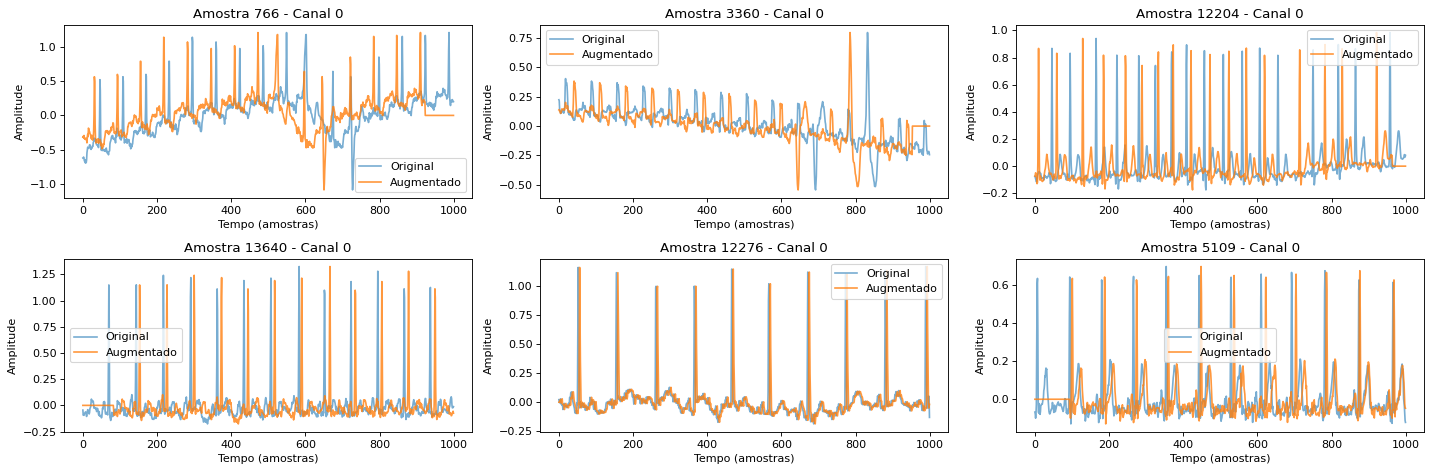

0epoch [00:00, ?epoch/s]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1070/1070 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - auc_macro: 0.7029 - loss: 0.4821 - val_auc_macro: 0.8526 - val_loss: 0.3790 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.8565 - loss: 0.3695 - val_auc_macro: 0.8774 - val_loss: 0.3476 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.8842 - loss: 0.3321 - val_auc_macro: 0.8880 - val_loss: 0.3343 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.8916 - loss: 0.3208 - val_auc_macro: 0.8910 - val_loss: 0.3357 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.9003 - loss: 0.3079 - val_auc_macro: 0.8970 - val_loss: 0.3290 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_macro: 0.9031 - loss: 0.3046 - val_auc_macro: 0.9002 - val_loss: 0.3221 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - auc_macro: 

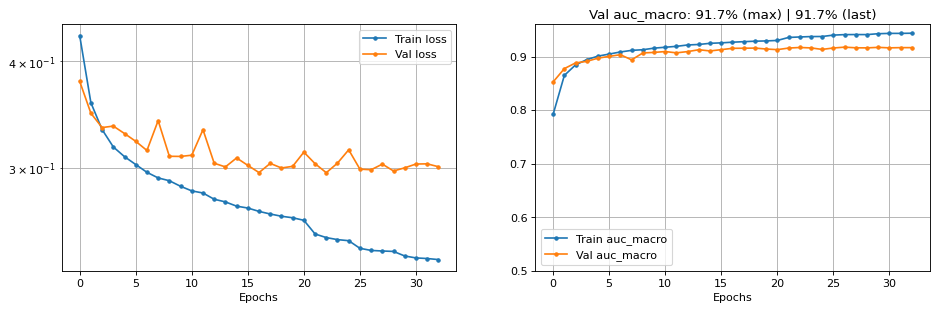

In [161]:
from tqdm.keras import TqdmCallback
history = train_class(
    model,
    x_train, y_train_class,
    x_val, y_val_class,
    flag = 2,
    epochs=100,
    batch_size=16,
    lr=0.0011,  
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        reduce_lr  
    ],
    n_classes=5
)
plots(history, ylim=[0.5, 0.96])

### Conjunto de teste - Data Aug 2

In [162]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model6_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.2920
Acurácia no Teste: 0.9121


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Macro AUC: 0.9121
Test AUC Classe 0: 0.9382
Test AUC Classe 1: 0.9222
Test AUC Classe 2: 0.9257
Test AUC Classe 3: 0.8830
Test AUC Classe 4: 0.8913


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.291984,0.912069,0.912065,0.938186,0.922197,0.925658,0.88298,0.891305


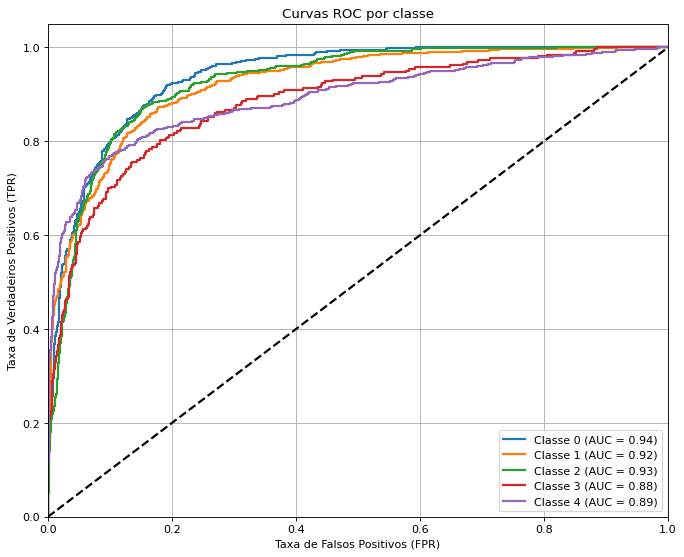

In [163]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model6_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model6_results_df[f'auc_class_{i}'] = auc_test

display(test_model6_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [164]:
test_model6_results_df.index = ["teste modelo data augmentation time shift"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model6_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085
"teste modelo sofia (otimizado, sem batch normalization)",0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.893240
teste modelo data augmentation padding 0,0.292726,0.913318,0.913242,0.935122,0.925770,0.926661,0.881597,0.897061
teste modelo data augmentation time shift,0.291984,0.912069,0.912065,0.938186,0.922197,0.925658,0.882980,0.891305


### Data Augmentation 3

In [165]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_72 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_72 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_73 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_73 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_74 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_74 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_75 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_75 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_76 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_76 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_12          │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,893 (54.27 KB)

 Trainable params: 13,829 (54.02 KB)

 Non-trainable params: 64 (256.00 B)

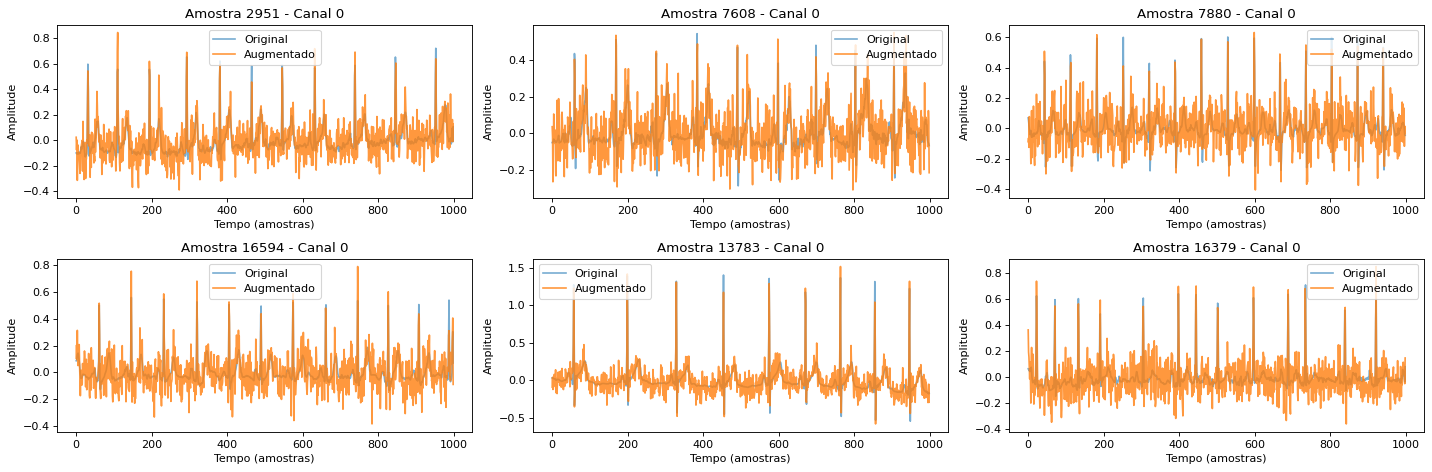

0epoch [00:00, ?epoch/s]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1070/1070 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - auc_macro: 0.6807 - loss: 0.4956 - val_auc_macro: 0.8496 - val_loss: 0.3827 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8549 - loss: 0.3708 - val_auc_macro: 0.8753 - val_loss: 0.3508 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - auc_macro: 0.8857 - loss: 0.3321 - val_auc_macro: 0.8838 - val_loss: 0.3476 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8907 - loss: 0.3236 - val_auc_macro: 0.8806 - val_loss: 0.3889 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - auc_macro: 0.8952 - loss: 0.3162 - val_auc_macro: 0.8946 - val_loss: 0.3299 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.9038 - loss: 0.3071 - val_auc_macro: 0.8972 - val_loss: 0.3225 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - auc_macro: 

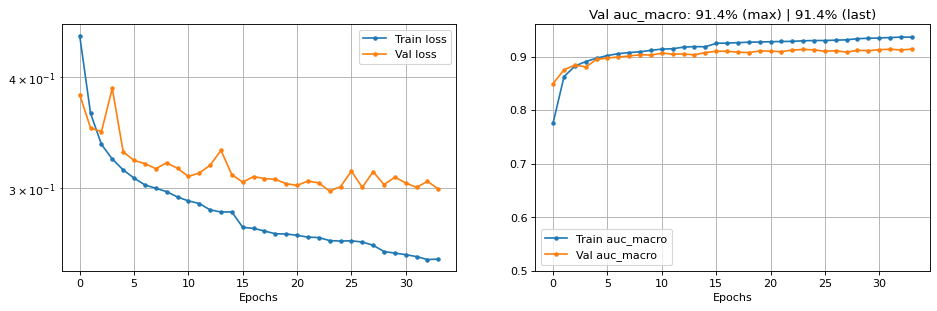

In [166]:
from tqdm.keras import TqdmCallback
history = train_class(
    model,
    x_train, y_train_class,
    x_val, y_val_class,
    flag = 3,
    epochs=100,
    batch_size=16,
    lr=0.0011,  
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        reduce_lr  
    ],
    n_classes=5
)
plots(history, ylim=[0.5, 0.96])

### Conjunto de teste - Data Aug 3

In [167]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model7_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.2982
Acurácia no Teste: 0.9086


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Macro AUC: 0.9088
Test AUC Classe 0: 0.9263
Test AUC Classe 1: 0.9184
Test AUC Classe 2: 0.9254
Test AUC Classe 3: 0.8782
Test AUC Classe 4: 0.8958


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.298196,0.908572,0.908808,0.926262,0.918383,0.925403,0.878185,0.895807


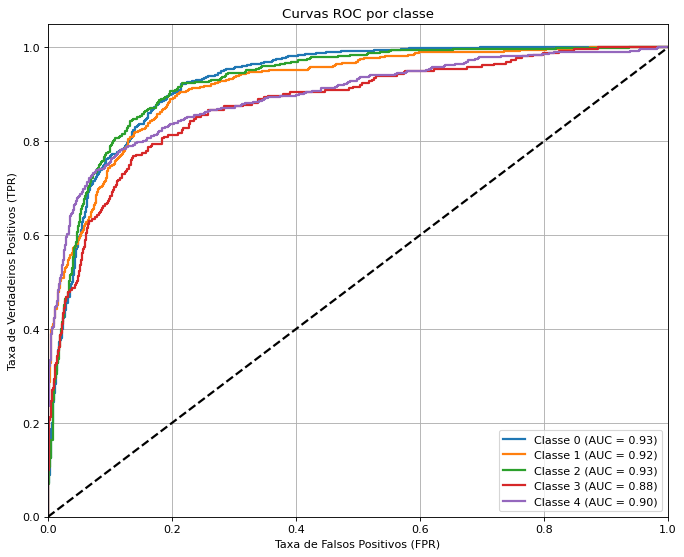

In [168]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model7_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model7_results_df[f'auc_class_{i}'] = auc_test

display(test_model7_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [169]:
test_model7_results_df.index = ["teste modelo data augmentation ruido"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model7_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085
"teste modelo sofia (otimizado, sem batch normalization)",0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.893240
teste modelo data augmentation padding 0,0.292726,0.913318,0.913242,0.935122,0.925770,0.926661,0.881597,0.897061
teste modelo data augmentation time shift,0.291984,0.912069,0.912065,0.938186,0.922197,0.925658,0.882980,0.891305
teste modelo data augmentation ruido,0.298196,0.908572,0.908808,0.926262,0.918383,0.925403,0.878185,0.895807


### Data Augmentation 4

In [170]:

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(1000, 12)),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.Conv1D(filters=32, kernel_size=3, padding='same'),
    layers.LeakyReLU(alpha=0.0088),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),

    layers.Dense(5, activation='sigmoid')  # 5 superclasses (para classificação multi-label)
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_77 (Conv1D)                   │ (None, 1000, 32)            │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_77 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_78 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_78 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_79 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_79 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_80 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_80 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_81 (Conv1D)                   │ (None, 1000, 32)            │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_81 (LeakyReLU)           │ (None, 1000, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_13          │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,893 (54.27 KB)

 Trainable params: 13,829 (54.02 KB)

 Non-trainable params: 64 (256.00 B)

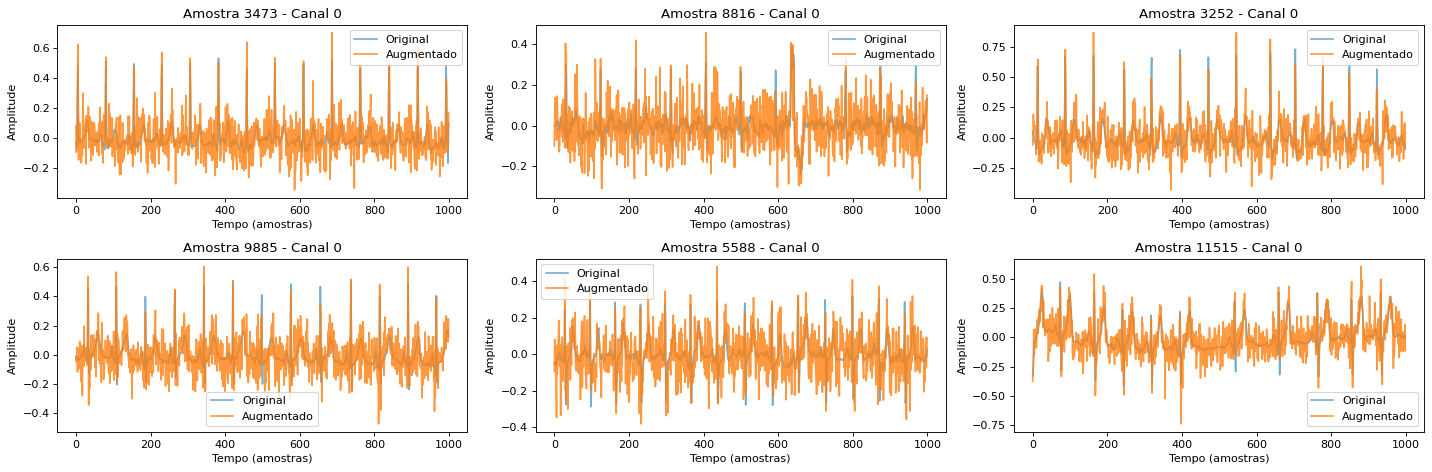

0epoch [00:00, ?epoch/s]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1070/1070 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - auc_macro: 0.6894 - loss: 0.4960 - val_auc_macro: 0.8452 - val_loss: 0.3922 - learning_rate: 0.0011
Epoch 2/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8512 - loss: 0.3764 - val_auc_macro: 0.8703 - val_loss: 0.3606 - learning_rate: 0.0011
Epoch 3/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8777 - loss: 0.3452 - val_auc_macro: 0.8836 - val_loss: 0.3434 - learning_rate: 0.0011
Epoch 4/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8899 - loss: 0.3257 - val_auc_macro: 0.8903 - val_loss: 0.3338 - learning_rate: 0.0011
Epoch 5/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - auc_macro: 0.8971 - loss: 0.3168 - val_auc_macro: 0.8917 - val_loss: 0.3333 - learning_rate: 0.0011
Epoch 6/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc_macro: 0.8985 - loss: 0.3120 - val_auc_macro: 0.8951 - val_loss: 0.3250 - learning_rate: 0.0011
Epoch 7/100
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - auc_macro: 

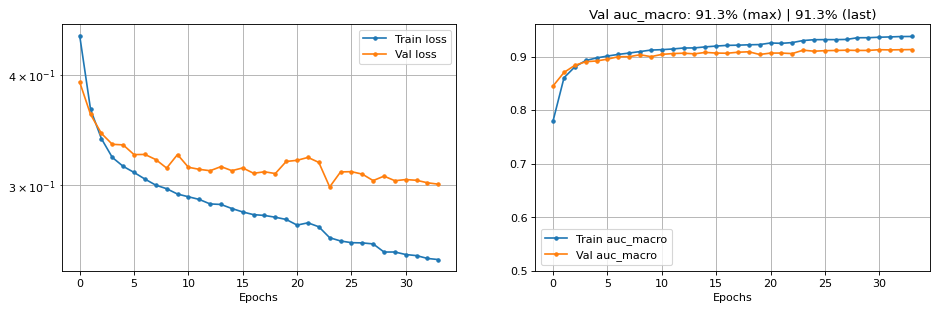

In [171]:
from tqdm.keras import TqdmCallback
history = train_class(
    model,
    x_train, y_train_class,
    x_val, y_val_class,
    flag = 3,
    epochs=100,
    batch_size=16,
    lr=0.0011,  
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        reduce_lr  
    ],
    n_classes=5
)
plots(history, ylim=[0.5, 0.96])

### Conjunto de teste - Data Aug 4

In [172]:
test_loss, test_acc = model.evaluate(x_test, y_test_class, verbose=0)
print(f"Loss no Teste: {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc:.4f}")
test_model8_results_df = pd.DataFrame({
    'loss': [test_loss],
    'own_accuracy': [test_acc]
})

Loss no Teste: 0.2951
Acurácia no Teste: 0.9098


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Macro AUC: 0.9100
Test AUC Classe 0: 0.9291
Test AUC Classe 1: 0.9209
Test AUC Classe 2: 0.9225
Test AUC Classe 3: 0.8801
Test AUC Classe 4: 0.8975


,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
0,0.295114,0.909783,0.910015,0.929106,0.920932,0.922505,0.88008,0.89745


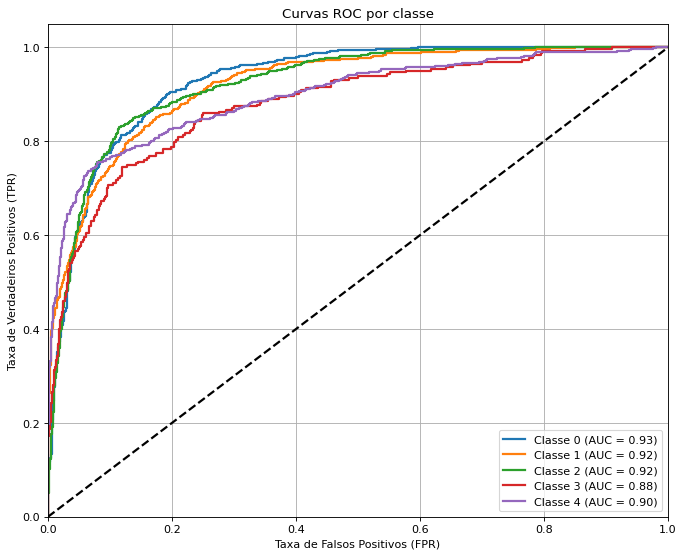

In [173]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Certifique-se de usar arrays numpy
y_test_true = y_test_class.to_numpy() if hasattr(y_test_class, 'to_numpy') else y_test_class
y_test_pred = model.predict(x_test)

# AUC macro
auc_macro_test = roc_auc_score(y_test_true, y_test_pred, average='macro')
print(f"Test Macro AUC: {auc_macro_test:.4f}")

# AUC por classe (corrigido)
auc_per_class = []
for i in range(y_test_true.shape[1]):
    class_auc = roc_auc_score(y_test_true[:, i], y_test_pred[:, i])
    auc_per_class.append(class_auc)
    print(f"Test AUC Classe {i}: {class_auc:.4f}")


test_model8_results_df['auc_macro'] = auc_macro_test
for i, auc_test in enumerate(auc_per_class):
    test_model8_results_df[f'auc_class_{i}'] = auc_test

display(test_model8_results_df)


n_classes = y_test_true.shape[1]
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_true[:, i], y_test_pred[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {class_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC por classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [174]:
test_model8_results_df.index = ["teste modelo data augmentation amplitude"]

# Concatene os dois dataframes
resultados_df = pd.concat([resultados_df, test_model8_results_df])

# Exibe o resultado
display(resultados_df)

,loss,own_accuracy,auc_macro,auc_class_0,auc_class_1,auc_class_2,auc_class_3,auc_class_4
teste nosso modelo,1.348525,0.808508,0.858480,0.891681,0.868923,0.885849,0.803129,0.842821
teste modelo smiegel multi label,0.301581,0.908518,0.908831,0.928003,0.918929,0.922688,0.877697,0.896839
"teste modelo sofia (otimizado, com batch normalization)",0.291947,0.913139,0.913098,0.934342,0.924873,0.922444,0.879748,0.904085
"teste modelo sofia (otimizado, sem batch normalization)",0.302645,0.906068,0.906106,0.928796,0.913977,0.916033,0.878482,0.893240
teste modelo data augmentation padding 0,0.292726,0.913318,0.913242,0.935122,0.925770,0.926661,0.881597,0.897061
teste modelo data augmentation time shift,0.291984,0.912069,0.912065,0.938186,0.922197,0.925658,0.882980,0.891305
teste modelo data augmentation ruido,0.298196,0.908572,0.908808,0.926262,0.918383,0.925403,0.878185,0.895807
teste modelo data augmentation amplitude,0.295114,0.909783,0.910015,0.929106,0.920932,0.922505,0.880080,0.897450


### Análise de resultados

A partir desse notebook foi possível perceber que o melhor resultado que tivemos foi o modelo com hiperparâmetros otimizados com batch normalization. Assim, esse modelo com batch normalization foi retreinado com diferentes tipos de data augmentation sem um ganho evidente nas métricas.
Tudo isso indica que, para desenvolver um modelo melhor, uma melhor alternativa poderia ser deixar a rede mais complexa ou até desenvolver um feature engineering com processamento do sinal de ECG, extraindo novas features e até montando uma nova arquitetura do que as que foram vistas nesse notebook.
Percebe-se também que a classe de hipertrofia foi a que teve piores métricas, além de sera com menos dados no dataset. Isso corrobora com a afirmação de que um modelo tem métricas que são diretamente proporcionais a qualidade dos dados que o alimentam.
Uma última ideia pode ser realizar um benchmark com as 23 subclasses do dataset, isso pode ser uma análise interessante.